# Estudio con distribución normal

En este notebook se ejecuta y comenta la ejecución del experimento con brazos cuya recompensa viene dada por una función de distribución normal.

## Constantes

In [1]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/ucb1_bernoulli_dist"

## Librerías

In [2]:
import sys
import random

import numpy as np
from typing import List

sys.path.append('./src')
print(sys.path)

from arms import ArmBernoulli, Bandit
from experiment import run_experiment
from algorithms import Algorithm, EpsilonGreedy, SoftMax, UCB1
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['/home/denis/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python312.zip', '/home/denis/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12', '/home/denis/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/lib-dynload', '', '/home/denis/Documents/mia-um/eml/dourado-minguell-eml-mia-um-p1/.venv/lib/python3.12/site-packages', './src']


## Reproducibilidad

In [3]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Para cada algiritmo $\epsilon$-greedy, softmax y UCB1, se ejecuta la experimentación del problema del bandido de k-brazos durante el número de pasos y ejecuciones definido en las constantes. Posteriormente, para cada algoritmo se realiza el pertienente estudio de resultados mediantes las gráficas de recompensas promedio, selecciones óptimas, arrepentimiento y estadísticas por brazo.

In [4]:
# Creación del bandido de k-brazos
bandit = Bandit(arms=ArmBernoulli.generate_arms(K))
optimal_arm = bandit.optimal_arm

print(bandit)
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmBernoulli (np=0.37), ArmBernoulli (np=0.95), ArmBernoulli (np=0.6), ArmBernoulli (np=0.73), ArmBernoulli (np=0.16), ArmBernoulli (np=0.06), ArmBernoulli (np=0.87), ArmBernoulli (np=0.71), ArmBernoulli (np=0.97), ArmBernoulli (np=0.02)
Optimal arm: 9 with expected reward=0.97


Para le experimentación, se va emplear un bandido de 10 brazos. Para este caso reproducible, el brazo óptimo es el número 8 con una recomensa media esperada de 9.56.

### Algoritmo UCB1

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 0.1. Se realizan 500 ejecuciones de ~1000~5000 pasos cada una.
Se contrastan:
 - UCB1 con valor $exploration = 0$
 - UCB1 con valor $exploration = 0.1$
 - UCB1 con valor $exploration = 1$
 - UCB1 con valor $exploration = 5$
 - UCB1 con valor $exploration = 10$

In [5]:
# Definir los algoritmos softmax con diferente temperatura
algorithms_ucb1 = [
    UCB1(k=K, exploration=0),
    UCB1(k=K, exploration=0.1),
    UCB1(k=K, exploration=1),
    UCB1(k=K, exploration=5)
]

# Ejecutar el experimento
rewards_ucb1, optimal_selections_ucb1, regret_accumulated_ucb1, arm_stats_ucb1 = run_experiment(bandit, algorithms_ucb1, STEPS, RUNS)

Desde un primer vistazo el comportamiento de todos los algoritmos USB1 sorprende por su recompensa promedio. Vemos como los distintos parametros empleados para la variante exploration parecen afectar en menor medida que para los otros algoritmos del estudio. En este caso todas las versiones alcanzan un valor de recompensa promedio muy proximo al valor optimo, tan solo afectando a la velocidad con la que se alcanza esa precisión.


En las dos siguientes gráficas se aprecian más diferencias que permiten valorar de manera más apropiada su comportamiento. En el caso de selecciones optimas vemos como cuando el termino  exploration = 0 el algoritmo no presenta componente exploratoria y, por tanto, se comporta similar que los otros dos algoritmos: alcanzando rapidamente una precisión del ~85% pero no aprendiendo con el paso de las iteraciones. Lo mismo ocurre con exploration = 0.1 y 1 pero con un mayor porcentaje de acierto en cada caso, alcanzando el ~100% de acierto en el segundo caso. Por su parte, las versiones con mayor componente exploratoria tardan más en aprender.

Este menor ritmo de aprendizaje se refleja en un mayor arrepentimiento acumulado frente a las otras alternativas, siendo nuevamente exploration = 1 la variante que presenta un mejor comportamiento.

#### Recompensas promedio

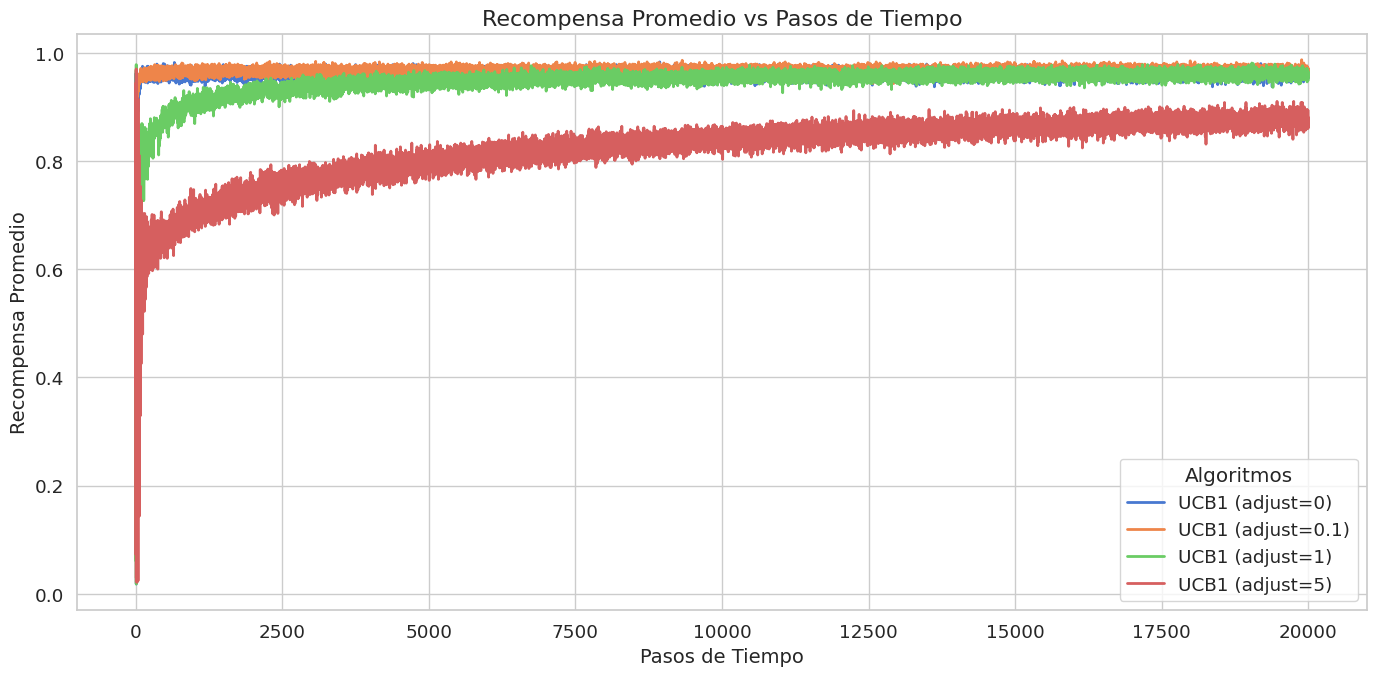

In [6]:
plot_average_rewards(STEPS, rewards_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

#### Selecciones óptimas

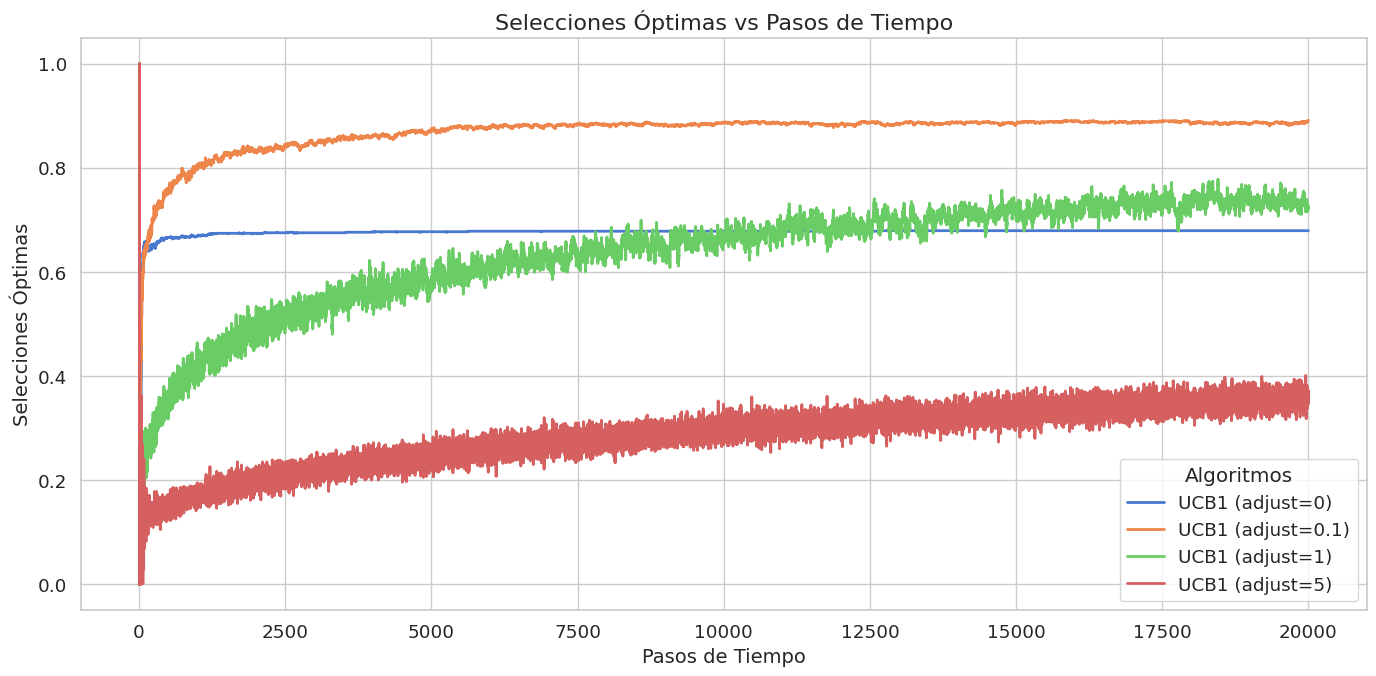

In [7]:
plot_optimal_selections(STEPS, optimal_selections_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

Tras esta primera sección vamos a realizar la comprobación con los algoritmos que mejor comportamiento presentan a 5000 iteraciones. Para realizar este elección se va a realizar una elección basada en la recompensa promedio y el arrepentimiento acumulado:

 - epsilon greedy con valor $\epsilon = 0$
 - epsilon greedy con valor $\epsilon = 0.1$
 - SoftMax con valor $temperature = 0.001$
 - SoftMax con valor $temperature = 0.1$
 - UCB1 con valor $exploration = 0.1$
 - UCB1 con valor $exploration = 1$

#### Arrepentimiento

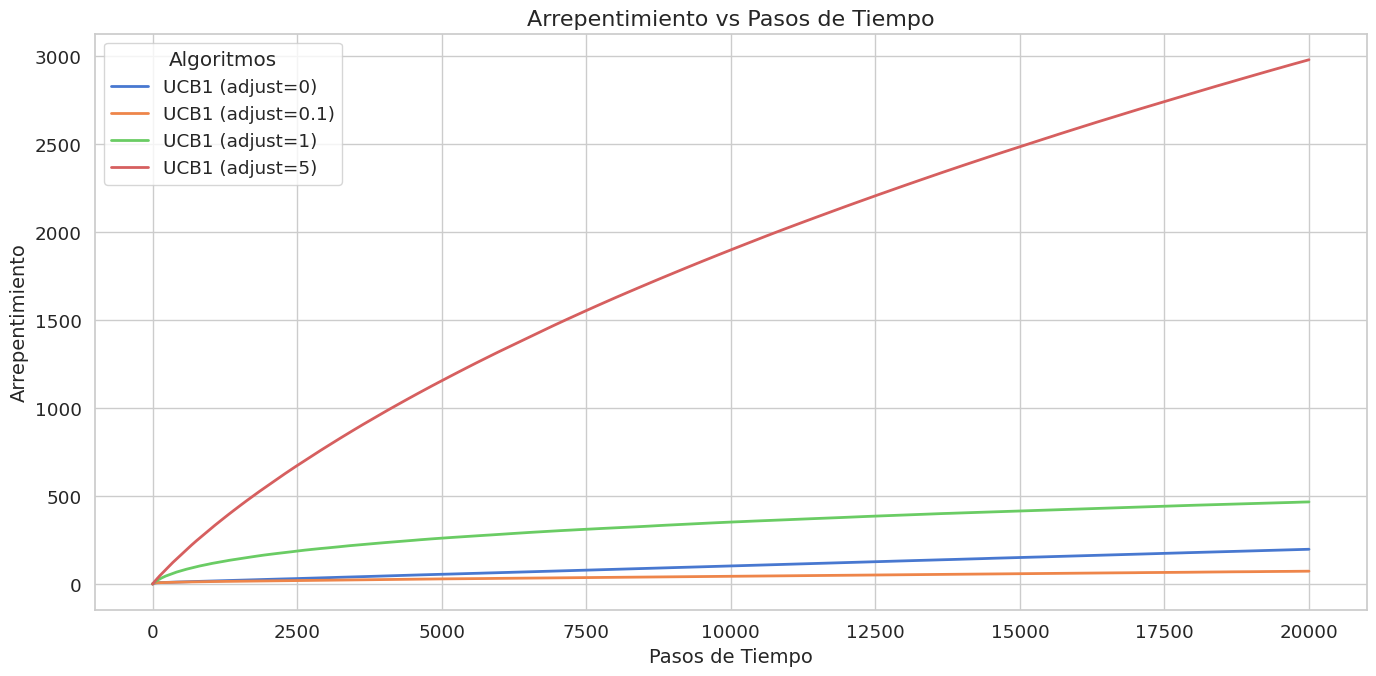

In [8]:
plot_regret(STEPS, regret_accumulated_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

#### Estadísticas por brazo

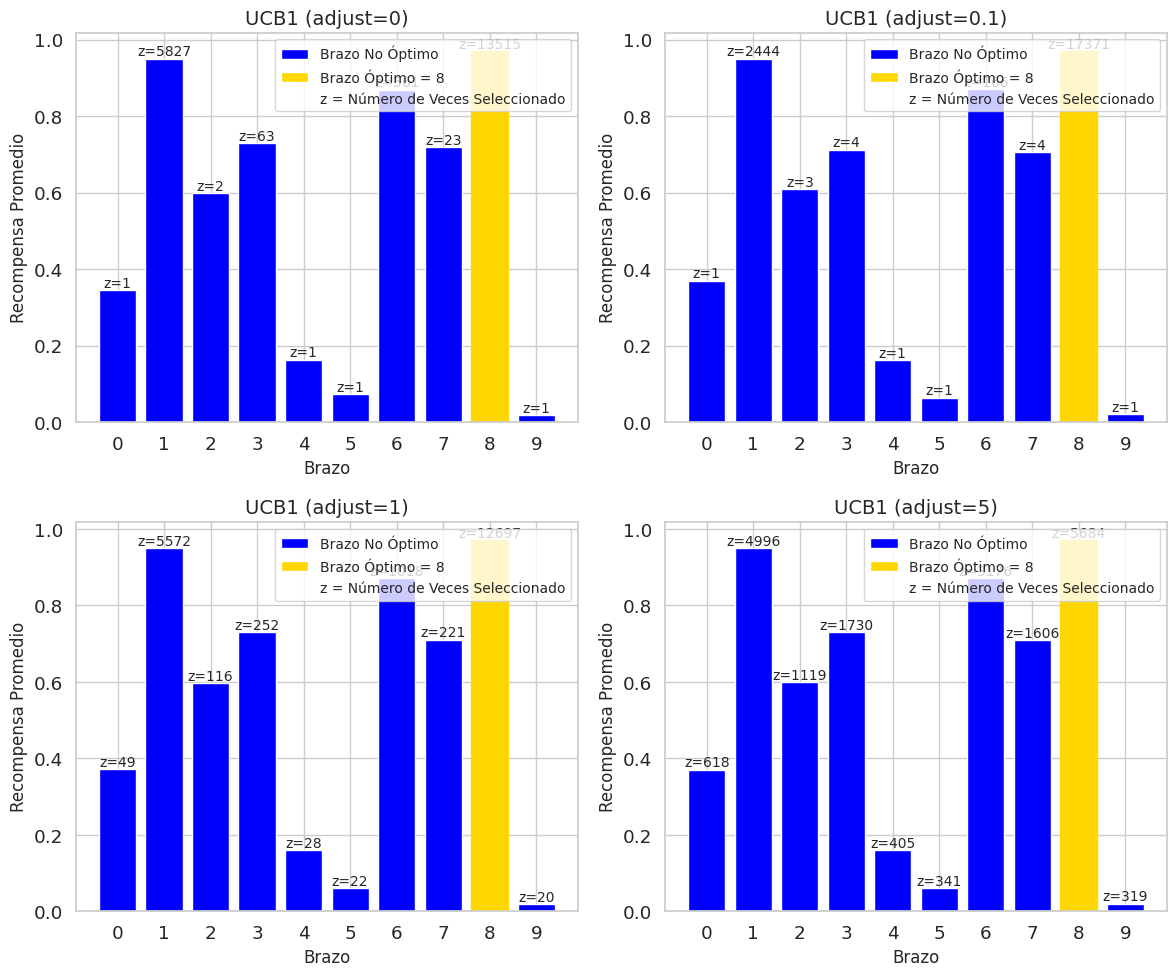

In [9]:
plot_arm_statistics(arm_stats_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

## Conclusiones